In [21]:
import os, time
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import svd, eigh, eig, LinAlgError
from scipy.sparse.linalg import LinearOperator, eigsh

np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

FIGDIR = "figureAKLT"
os.makedirs(FIGDIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIGDIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("saved:", path)

def spin_half_ops(dtype=np.complex128):
    I = np.eye(2, dtype=dtype)
    Sp = np.array([[0, 1], [0, 0]], dtype=dtype)
    Sm = np.array([[0, 0], [1, 0]], dtype=dtype)
    Sz = np.array([[0.5, 0], [0, -0.5]], dtype=dtype)
    Sx = 0.5 * (Sp + Sm)
    Sy = -0.5j * (Sp - Sm)
    return {"I": I, "Sp": Sp, "Sm": Sm, "Sz": Sz, "Sx": Sx, "Sy": Sy}

def spin_one_ops(dtype=np.complex128):
    I = np.eye(3, dtype=dtype)
    Sx = (1/np.sqrt(2)) * np.array([[0, 1, 0],
                                    [1, 0, 1],
                                    [0, 1, 0]], dtype=dtype)
    Sy = (1j/np.sqrt(2)) * np.array([[0, -1, 0],
                                     [1,  0, -1],
                                     [0,  1, 0]], dtype=dtype)
    Sz = np.array([[1, 0, 0],
                   [0, 0, 0],
                   [0, 0, -1]], dtype=dtype)
    return {"I": I, "Sx": Sx, "Sy": Sy, "Sz": Sz}

In [22]:
def mpo_heisenberg(L, J=1.0, Jz=1.0, h=0.0, dtype=np.complex128):
    ops = spin_half_ops(dtype=dtype)
    I, Sp, Sm, Sz = ops["I"], ops["Sp"], ops["Sm"], ops["Sz"]

    Dw, d = 5, 2
    Wbulk = np.zeros((Dw, Dw, d, d), dtype=dtype)

    Wbulk[0, 0] = I
    Wbulk[1, 0] = Sp
    Wbulk[2, 0] = Sm
    Wbulk[3, 0] = Sz
    Wbulk[4, 0] = -h * Sz
    Wbulk[4, 1] = (J/2) * Sm
    Wbulk[4, 2] = (J/2) * Sp
    Wbulk[4, 3] = Jz * Sz
    Wbulk[4, 4] = I

    Wleft = np.zeros((1, Dw, d, d), dtype=dtype)
    Wright = np.zeros((Dw, 1, d, d), dtype=dtype)
    Wleft[0] = Wbulk[4]
    Wright[:, 0] = Wbulk[:, 0]

    Wlist = [Wleft] + [Wbulk.copy() for _ in range(1, L-1)] + [Wright]
    return Wlist, 4, 0

In [23]:
def mpo_aklt(L, dtype=np.complex128):
    ops = spin_one_ops(dtype=dtype)
    I, Sx, Sy, Sz = ops["I"], ops["Sx"], ops["Sy"], ops["Sz"]

    Svec = [Sx, Sy, Sz]
    Qvec = [Sa @ Sb for Sa in Svec for Sb in Svec]

    Dw, d = 14, 3
    Wbulk = np.zeros((Dw, Dw, d, d), dtype=dtype)

    Wbulk[0, 0] = I
    for a in range(3):
        Wbulk[1+a, 0] = Svec[a]
    for q in range(9):
        Wbulk[4+q, 0] = Qvec[q]
    for a in range(3):
        Wbulk[13, 1+a] = Svec[a]
    for q in range(9):
        Wbulk[13, 4+q] = (1/3.0) * Qvec[q]
    Wbulk[13, 13] = I

    Wleft = np.zeros((1, Dw, d, d), dtype=dtype)
    Wright = np.zeros((Dw, 1, d, d), dtype=dtype)
    Wleft[0] = Wbulk[13]
    Wright[:, 0] = Wbulk[:, 0]

    Wlist = [Wleft] + [Wbulk.copy() for _ in range(1, L-1)] + [Wright]
    return Wlist, 13, 0

In [24]:
def aklt_bulk_matrices(dtype=np.complex128):
    Aplus = np.array([[0, np.sqrt(2/3)],
                      [0, 0]], dtype=dtype)
    A0 = np.array([[-1/np.sqrt(3), 0],
                   [0,  1/np.sqrt(3)]], dtype=dtype)
    Aminus = np.array([[0, 0],
                       [-np.sqrt(2/3), 0]], dtype=dtype)
    return [Aplus, A0, Aminus]

def aklt_exact_mps(L, dtype=np.complex128):
    Aplus, A0, Aminus = aklt_bulk_matrices(dtype=dtype)
    Abulk = np.stack([Aplus, A0, Aminus], axis=1)  # (2,3,2)
    vL = np.array([[1.0, 0.0]], dtype=dtype)
    vR = np.array([[1.0], [0.0]], dtype=dtype)

    mps = []
    for i in range(L):
        if i == 0:
            T = np.tensordot(vL, Abulk, axes=([1], [0]))
        elif i == L - 1:
            T = np.tensordot(Abulk, vR, axes=([2], [0]))
        else:
            T = Abulk.copy()
        mps.append(T.astype(dtype))
    return mps

def mps_overlap(mps_bra, mps_ket):
    env = np.array([[1.0+0j]], dtype=np.complex128)
    for A, B in zip(mps_bra, mps_ket):
        env = np.einsum("xy,xsX,ysY->XY", env, A.conj(), B, optimize=True)
    return env[0, 0]

def normalize_mps(mps):
    nrm = np.sqrt(np.abs(mps_overlap(mps, mps)))
    out = [A.copy() for A in mps]
    out[0] /= nrm
    return out

def random_mps(L, d, Dmax, seed=1234, dtype=np.complex128):
    rng = np.random.default_rng(seed)
    dims = [1]
    for _ in range(1, L):
        dims.append(min(Dmax, dims[-1] * d))
    dims.append(1)
    for i in range(L-1, 0, -1):
        dims[i] = min(dims[i], dims[i+1] * d)

    mps = []
    for i in range(L):
        Dl, Dr = dims[i], dims[i+1]
        A = rng.normal(size=(Dl, d, Dr)) + 1j * rng.normal(size=(Dl, d, Dr))
        A = A.astype(dtype)
        A /= np.linalg.norm(A)
        mps.append(A)
    return mps

In [25]:
def robust_svd(M):
    try:
        U, s, Vh = svd(M, full_matrices=False)
    except LinAlgError:
        U, s, Vh = svd(M, full_matrices=False, lapack_driver='gesvd')
    idx = np.argsort(s)[::-1]
    return U[:, idx], s[idx], Vh[idx, :]

def truncate_svd(U, s, Vh, Dmax, eps=1e-12, eps_abs=1e-14):
    if s[0] < eps_abs:
        D = 1
    else:
        D = np.sum(s > max(eps * s[0], eps_abs))
        D = max(1, min(Dmax, D))
    discarded = np.sum(s[D:]**2).real
    return U[:, :D], s[:D], Vh[:D, :], discarded

def left_canonicalize(mps):
    out = [A.copy() for A in mps]
    C = np.array([[1.0+0j]], dtype=np.complex128)
    for i in range(len(out)-1):
        A = np.tensordot(C, out[i], axes=([1], [0]))
        Dl, d, Dr = A.shape
        M = A.reshape(Dl*d, Dr, order='C')
        Q, R = np.linalg.qr(M, mode='reduced')
        out[i] = Q.reshape(Dl, d, Q.shape[1], order='C')
        C = R
    out[-1] = np.tensordot(C, out[-1], axes=([1], [0]))
    return out

def right_canonicalize(mps, Dmax=None, eps=1e-12):
    out = [A.copy() for A in mps]
    G = np.array([[1.0+0j]], dtype=np.complex128)
    for i in range(len(out)-1, 0, -1):
        A = np.tensordot(out[i], G, axes=([2], [0]))
        Dl, d, Dr = A.shape
        M = A.reshape(Dl, d*Dr, order='C')
        U, s, Vh = robust_svd(M)
        if Dmax is not None:
            U, s, Vh, _ = truncate_svd(U, s, Vh, Dmax=Dmax, eps=eps)
        out[i] = Vh.reshape(len(s), d, Dr, order='C')
        G = U @ np.diag(s)
    out[0] = np.tensordot(out[0], G, axes=([2], [0]))
    return out

In [26]:
def update_left_env(Lold, A, W):
    return np.einsum("bxy,ytY,bBst,xsX->BXY", Lold, A, W, A.conj(), optimize=True)

def update_right_env(Rold, A, W):
    return np.einsum("BXY,ytY,bBst,xsX->bxy", Rold, A, W, A.conj(), optimize=True)

def build_left_envs(mps, Wlist, b_left):
    L_env = [None] * len(mps)
    L_env[0] = np.zeros((Wlist[0].shape[1], 1, 1), dtype=np.complex128)
    L_env[0][b_left, 0, 0] = 1.0
    for i in range(len(mps)-1):
        L_env[i+1] = update_left_env(L_env[i], mps[i], Wlist[i])
    return L_env

def build_right_envs(mps, Wlist, b_right):
    R_env = [None] * len(mps)
    R_env[-1] = np.zeros((Wlist[-1].shape[0], 1, 1), dtype=np.complex128)
    R_env[-1][b_right, 0, 0] = 1.0
    for i in range(len(mps)-1, 0, -1):
        R_env[i-1] = update_right_env(R_env[i], mps[i], Wlist[i])
    return R_env

def mpo_expectation(mps, Wlist):
    env = np.array([[[1.0+0j]]], dtype=np.complex128)
    for A, W in zip(mps, Wlist):
        env = np.einsum("bxy,xsX,bBst,ytY->BXY", env, A.conj(), W, A, optimize=True)
    return env[0, 0, 0]

In [27]:
def apply_effective_hamiltonian(v, Lenv, W, Renv, shape):
    Dl, d, Dr = shape
    V = v.reshape((Dl, d, Dr), order='C')
    T1 = np.einsum("bxy,ytY->bxtY", Lenv, V, optimize=True)
    T2 = np.einsum("bxtY,bBst->BxsY", T1, W, optimize=True)
    Vnew = np.einsum("BxsY,BXY->xsX", T2, Renv, optimize=True)
    return Vnew.reshape(-1, order='C')

def dense_local_hamiltonian(Lenv, W, Renv, shape):
    dim = np.prod(shape)
    H = np.zeros((dim, dim), dtype=np.complex128)
    for j in range(dim):
        e = np.zeros(dim, dtype=np.complex128)
        e[j] = 1.0
        H[:, j] = apply_effective_hamiltonian(e, Lenv, W, Renv, shape)
    return 0.5 * (H + H.conj().T)

def solve_local_ground_state(Lenv, W, Renv, Minit, tol=1e-10, maxiter=300, dense_cutoff=64):
    shape = Minit.shape
    dim = np.prod(shape)

    if dim <= dense_cutoff:
        H = dense_local_hamiltonian(Lenv, W, Renv, shape)
        vals, vecs = eigh(H)
        return vals[0].real, vecs[:, 0].reshape(shape, order='C')

    def matvec(x):
        return apply_effective_hamiltonian(x, Lenv, W, Renv, shape)

    Heff = LinearOperator((dim, dim), matvec=matvec, rmatvec=matvec, dtype=np.complex128)
    v0 = Minit.reshape(-1, order='C').copy()

    try:
        vals, vecs = eigsh(Heff, k=1, which='SA', v0=v0, tol=tol, maxiter=maxiter)
        return vals[0].real, vecs[:, 0].reshape(shape, order='C')
    except Exception:
        H = dense_local_hamiltonian(Lenv, W, Renv, shape)
        vals, vecs = eigh(H)
        return vals[0].real, vecs[:, 0].reshape(shape, order='C')

def move_center_right(M, Mnext, Dmax, eps=1e-12):
    Dl, d, Dr = M.shape
    Mmat = M.reshape(Dl*d, Dr, order='C')
    U, s, Vh = robust_svd(Mmat)
    U, s, Vh, discarded = truncate_svd(U, s, Vh, Dmax=Dmax, eps=eps)
    Aleft = U.reshape(Dl, d, len(s), order='C')
    gauge = np.diag(s) @ Vh
    new_next = np.tensordot(gauge, Mnext, axes=([1], [0]))
    return Aleft, new_next, discarded, s

def move_center_left(Mprev, M, Dmax, eps=1e-12):
    Dl, d, Dr = M.shape
    Mmat = M.reshape(Dl, d*Dr, order='C')
    U, s, Vh = robust_svd(Mmat)
    U, s, Vh, discarded = truncate_svd(U, s, Vh, Dmax=Dmax, eps=eps)
    Bright = Vh.reshape(len(s), d, Dr, order='C')
    gauge = U @ np.diag(s)
    new_prev = np.tensordot(Mprev, gauge, axes=([2], [0]))
    return new_prev, Bright, discarded, s

def single_site_dmrg_fast_stop(Wlist, mps, b_left, b_right, Dmax,
                               nsweeps=20, eig_tol=1e-10, svd_eps=1e-12,
                               energy_tol=1e-9, min_sweeps=2, verbose=True):
    mps = right_canonicalize([A.copy() for A in mps], Dmax=Dmax, eps=svd_eps)
    mps = normalize_mps(mps)

    energies, trunc_hist, entropy_hist = [], [], []

    for sweep in range(nsweeps):
        R_env = build_right_envs(mps, Wlist, b_right)
        Lenv = np.zeros((Wlist[0].shape[1], 1, 1), dtype=np.complex128)
        Lenv[b_left, 0, 0] = 1.0

        last_E = None
        sweep_disc, sweep_S = [], []

        for i in range(len(mps)-1):
            E, Mopt = solve_local_ground_state(Lenv, Wlist[i], R_env[i], mps[i], tol=eig_tol)
            last_E = E
            Aleft, new_next, disc, s = move_center_right(Mopt, mps[i+1], Dmax=Dmax, eps=svd_eps)
            mps[i], mps[i+1] = Aleft, new_next
            Lenv = update_left_env(Lenv, mps[i], Wlist[i])
            sweep_disc.append(disc)
            p = np.abs(s)**2
            p = p / np.sum(p)
            p = p[p > 1e-15]
            sweep_S.append(float(-(p * np.log(p)).sum().real))

        E, Mopt = solve_local_ground_state(Lenv, Wlist[-1], R_env[-1], mps[-1], tol=eig_tol)
        mps[-1] = Mopt
        last_E = E

        L_env = build_left_envs(mps, Wlist, b_left)
        Renv = np.zeros((Wlist[-1].shape[0], 1, 1), dtype=np.complex128)
        Renv[b_right, 0, 0] = 1.0

        for i in range(len(mps)-1, 0, -1):
            E, Mopt = solve_local_ground_state(L_env[i], Wlist[i], Renv, mps[i], tol=eig_tol)
            last_E = E
            new_prev, Bright, disc, s = move_center_left(mps[i-1], Mopt, Dmax=Dmax, eps=svd_eps)
            mps[i-1], mps[i] = new_prev, Bright
            Renv = update_right_env(Renv, mps[i], Wlist[i])
            sweep_disc.append(disc)
            p = np.abs(s)**2
            p = p / np.sum(p)
            p = p[p > 1e-15]
            sweep_S.append(float(-(p * np.log(p)).sum().real))

        E, Mopt = solve_local_ground_state(L_env[0], Wlist[0], Renv, mps[0], tol=eig_tol)
        mps[0] = Mopt
        last_E = E

        mps = normalize_mps(mps)

        energies.append(float(last_E))
        trunc_hist.append(float(np.sum(sweep_disc).real))
        entropy_hist.append(float(max(sweep_S) if len(sweep_S) else 0.0))

        dE = abs(energies[-1] - energies[-2]) if len(energies) >= 2 else np.nan
        if verbose:
            print(f"sweep {sweep+1:2d}: E = {energies[-1]: .12f}, dE = {dE:.3e}, trunc_sum = {trunc_hist[-1]:.3e}, Smax = {entropy_hist[-1]:.6f}")

        if (sweep+1) >= min_sweeps and len(energies) >= 2 and abs(energies[-1] - energies[-2]) < energy_tol:
            if verbose:
                print(f"Converged early: |dE| < {energy_tol}")
            break

    return mps, np.array(energies), np.array(trunc_hist), np.array(entropy_hist)

In [28]:
def merge_two_sites(A, B):
    return np.tensordot(A, B, axes=([2], [0]))

def apply_effective_hamiltonian_two_site(v, Lenv, W1, W2, Renv, shape):
    Dl, d1, d2, Dr = shape
    Theta = v.reshape((Dl, d1, d2, Dr), order='C')  # (y,t1,t2,Y)
    T1 = np.einsum("bxy,ytuY->bxtuY", Lenv, Theta, optimize=True)
    T2 = np.einsum("bxtuY,bcst->cxsuY", T1, W1, optimize=True)
    T3 = np.einsum("cxsuY,cBvu->BxsvY", T2, W2, optimize=True)
    out = np.einsum("BxsvY,BXY->xsvX", T3, Renv, optimize=True)
    return out.reshape(-1, order='C')

def dense_two_site_hamiltonian(Lenv, W1, W2, Renv, shape):
    dim = np.prod(shape)
    H = np.zeros((dim, dim), dtype=np.complex128)
    for j in range(dim):
        e = np.zeros(dim, dtype=np.complex128)
        e[j] = 1.0
        H[:, j] = apply_effective_hamiltonian_two_site(e, Lenv, W1, W2, Renv, shape)
    return 0.5 * (H + H.conj().T)

def solve_two_site_ground_state(Lenv, W1, W2, Renv, Theta_init, tol=1e-10, maxiter=400, dense_cutoff=128):
    shape = Theta_init.shape
    dim = np.prod(shape)

    if dim <= dense_cutoff:
        H = dense_two_site_hamiltonian(Lenv, W1, W2, Renv, shape)
        vals, vecs = eigh(H)
        return vals[0].real, vecs[:, 0].reshape(shape, order='C')

    def matvec(x):
        return apply_effective_hamiltonian_two_site(x, Lenv, W1, W2, Renv, shape)

    Heff = LinearOperator((dim, dim), matvec=matvec, rmatvec=matvec, dtype=np.complex128)
    v0 = Theta_init.reshape(-1, order='C').copy()
    try:
        vals, vecs = eigsh(Heff, k=1, which='SA', v0=v0, tol=tol, maxiter=maxiter)
        return vals[0].real, vecs[:, 0].reshape(shape, order='C')
    except Exception:
        H = dense_two_site_hamiltonian(Lenv, W1, W2, Renv, shape)
        vals, vecs = eigh(H)
        return vals[0].real, vecs[:, 0].reshape(shape, order='C')

def split_two_sites_right(Theta, Dmax, eps=1e-12):
    Dl, d1, d2, Dr = Theta.shape
    M = Theta.reshape(Dl*d1, d2*Dr, order='C')
    U, s, Vh = robust_svd(M)
    U, s, Vh, discarded = truncate_svd(U, s, Vh, Dmax=Dmax, eps=eps)
    Aleft = U.reshape(Dl, d1, len(s), order='C')
    Bright = (np.diag(s) @ Vh).reshape(len(s), d2, Dr, order='C')
    return Aleft, Bright, discarded, s

def split_two_sites_left(Theta, Dmax, eps=1e-12):
    Dl, d1, d2, Dr = Theta.shape
    M = Theta.reshape(Dl*d1, d2*Dr, order='C')
    U, s, Vh = robust_svd(M)
    U, s, Vh, discarded = truncate_svd(U, s, Vh, Dmax=Dmax, eps=eps)
    Aleft = (U @ np.diag(s)).reshape(Dl, d1, len(s), order='C')
    Bright = Vh.reshape(len(s), d2, Dr, order='C')
    return Aleft, Bright, discarded, s

def two_site_dmrg(Wlist, mps, b_left, b_right, Dmax,
                  nsweeps=4, eig_tol=1e-10, svd_eps=1e-12,
                  energy_tol=None, min_sweeps=2, verbose=True):
    mps = right_canonicalize([A.copy() for A in mps], Dmax=Dmax, eps=svd_eps)
    mps = normalize_mps(mps)

    energies, trunc_hist = [], []

    for sweep in range(nsweeps):
        R_env = build_right_envs(mps, Wlist, b_right)
        Lenv = np.zeros((Wlist[0].shape[1], 1, 1), dtype=np.complex128)
        Lenv[b_left, 0, 0] = 1.0
        last_E = None
        sweep_disc = []

        # right sweep
        for i in range(len(mps)-1):
            Theta0 = merge_two_sites(mps[i], mps[i+1])
            E, Theta_opt = solve_two_site_ground_state(Lenv, Wlist[i], Wlist[i+1], R_env[i+1], Theta0, tol=eig_tol)
            last_E = E
            Aleft, Bright, disc, _ = split_two_sites_right(Theta_opt, Dmax=Dmax, eps=svd_eps)
            mps[i], mps[i+1] = Aleft, Bright
            Lenv = update_left_env(Lenv, mps[i], Wlist[i])
            sweep_disc.append(disc)

        # left sweep
        L_env = build_left_envs(mps, Wlist, b_left)
        Renv = np.zeros((Wlist[-1].shape[0], 1, 1), dtype=np.complex128)
        Renv[b_right, 0, 0] = 1.0

        for i in range(len(mps)-2, -1, -1):
            Theta0 = merge_two_sites(mps[i], mps[i+1])
            E, Theta_opt = solve_two_site_ground_state(L_env[i], Wlist[i], Wlist[i+1], Renv, Theta0, tol=eig_tol)
            last_E = E
            Aleft, Bright, disc, _ = split_two_sites_left(Theta_opt, Dmax=Dmax, eps=svd_eps)
            mps[i], mps[i+1] = Aleft, Bright
            Renv = update_right_env(Renv, mps[i+1], Wlist[i+1])
            sweep_disc.append(disc)

        mps = normalize_mps(mps)
        energies.append(float(last_E))
        trunc_hist.append(float(np.sum(sweep_disc).real))

        dE = abs(energies[-1] - energies[-2]) if len(energies) >= 2 else np.nan
        maxbond = max(A.shape[2] for A in mps[:-1])
        if verbose:
            print(f"sweep {sweep+1:2d}: E = {energies[-1]: .12f}, dE = {dE:.3e}, trunc_sum = {trunc_hist[-1]:.3e}, maxbond = {maxbond}")

        if energy_tol is not None and (sweep+1) >= min_sweeps and len(energies) >= 2:
            if abs(energies[-1] - energies[-2]) < energy_tol:
                if verbose:
                    print(f"Converged early: |dE| < {energy_tol}")
                break

    return mps, np.array(energies), np.array(trunc_hist)

In [29]:
def left_norm_environments(mps):
    envs = [None] * len(mps)
    env = np.array([[1.0+0j]], dtype=np.complex128)
    envs[0] = env
    for i in range(len(mps)-1):
        A = mps[i]
        env = np.einsum("ab,asA,bsB->AB", env, A.conj(), A, optimize=True)
        envs[i+1] = env
    return envs

def right_norm_environments(mps):
    envs = [None] * len(mps)
    env = np.array([[1.0+0j]], dtype=np.complex128)
    envs[-1] = env
    for i in range(len(mps)-1, 0, -1):
        A = mps[i]
        env = np.einsum("AB,asA,bsB->ab", env, A.conj(), A, optimize=True)
        envs[i-1] = env
    return envs

def one_site_expectation(mps, op, site):
    Lenvs = left_norm_environments(mps)
    Renvs = right_norm_environments(mps)
    A = mps[site]
    return np.einsum("ab,asA,st,btB,AB->", Lenvs[site], A.conj(), op, A, Renvs[site], optimize=True)

def two_point_expectation(mps, op_i, i, op_j, j):
    assert i <= j
    Lenvs = left_norm_environments(mps)
    Renvs = right_norm_environments(mps)
    env = Lenvs[i]
    A = mps[i]
    env = np.einsum("ab,asA,st,btB->AB", env, A.conj(), op_i, A, optimize=True)
    for site in range(i+1, j):
        A = mps[site]
        env = np.einsum("ab,asA,bsB->AB", env, A.conj(), A, optimize=True)
    A = mps[j]
    return np.einsum("ab,asA,st,btB,AB->", env, A.conj(), op_j, A, Renvs[j], optimize=True)

def connected_two_point(mps, op, i, j):
    return two_point_expectation(mps, op, i, op, j) - one_site_expectation(mps, op, i) * one_site_expectation(mps, op, j)

def mps_to_statevector(mps):
    psi = mps[0][0, :, :]
    for i in range(1, len(mps)):
        psi = np.tensordot(psi, mps[i], axes=([-1], [0]))
    psi = psi[..., 0]
    return np.asarray(psi, dtype=np.complex128).reshape(-1, order='C')

def exact_bond_entropies_from_state(mps):
    psi = mps_to_statevector(mps)
    psi = psi / np.linalg.norm(psi)
    L = len(mps)
    d = mps[0].shape[1]
    out = []
    for cut in range(1, L):
        M = psi.reshape((d**cut, d**(L-cut)), order='C')
        s = np.linalg.svd(M, compute_uv=False)
        p = np.abs(s)**2
        p = p / np.sum(p)
        p = p[p > 1e-15]
        out.append(float(-(p * np.log(p)).sum().real))
    return np.array(out)

def string_correlator(mps, op_left, string_op, op_right, i, j):
    assert i < j
    env = np.array([[1.0+0j]], dtype=np.complex128)
    for site, A in enumerate(mps):
        if site == i:
            env = np.einsum("xy,xsX,st,ytY->XY", env, A.conj(), op_left, A, optimize=True)
        elif i < site < j:
            env = np.einsum("xy,xsX,st,ytY->XY", env, A.conj(), string_op, A, optimize=True)
        elif site == j:
            env = np.einsum("xy,xsX,st,ytY->XY", env, A.conj(), op_right, A, optimize=True)
        else:
            env = np.einsum("xy,xsX,ysY->XY", env, A.conj(), A, optimize=True)
    return env[0, 0]

def kron_n(op_list):
    out = op_list[0]
    for op in op_list[1:]:
        out = np.kron(out, op)
    return out

def heisenberg_exact_hamiltonian(L, J=1.0, Jz=1.0, h=0.0, dtype=np.complex128):
    ops = spin_half_ops(dtype=dtype)
    I, Sp, Sm, Sz = ops["I"], ops["Sp"], ops["Sm"], ops["Sz"]
    H = np.zeros((2**L, 2**L), dtype=dtype)
    for i in range(L-1):
        term_pm, term_mp, term_zz = [], [], []
        for j in range(L):
            if j == i:
                term_pm.append(Sp); term_mp.append(Sm); term_zz.append(Sz)
            elif j == i+1:
                term_pm.append(Sm); term_mp.append(Sp); term_zz.append(Sz)
            else:
                term_pm.append(I); term_mp.append(I); term_zz.append(I)
        H += (J/2) * kron_n(term_pm)
        H += (J/2) * kron_n(term_mp)
        H += Jz * kron_n(term_zz)
    if abs(h) > 0:
        for i in range(L):
            term = [I] * L
            term[i] = Sz
            H += -h * kron_n(term)
    return H

def aklt_exact_hamiltonian(L, dtype=np.complex128):
    ops = spin_one_ops(dtype=dtype)
    I, Sx, Sy, Sz = ops["I"], ops["Sx"], ops["Sy"], ops["Sz"]
    SS = np.kron(Sx, Sx) + np.kron(Sy, Sy) + np.kron(Sz, Sz)
    h2 = SS + (1/3.0) * (SS @ SS)
    H = None
    for i in range(L-1):
        left = [I] * i
        right = [I] * (L - i - 2)
        HL = kron_n(left) if len(left) else np.array([[1.0]], dtype=dtype)
        HR = kron_n(right) if len(right) else np.array([[1.0]], dtype=dtype)
        term = np.kron(np.kron(HL, h2), HR)
        H = term if H is None else H + term
    return H

def variance_from_statevector(mps, H):
    psi = mps_to_statevector(mps)
    psi = psi / np.linalg.norm(psi)
    E = np.vdot(psi, H @ psi).real
    Hpsi = H @ psi
    H2 = np.vdot(Hpsi, Hpsi).real
    return E, H2, H2 - E**2

AKLT exact MPS energy = -6.000000000000001
AKLT exact formula    = -6.0
sweep  1: E = -5.999999997144, dE = nan, trunc_sum = 0.000e+00, Smax = 0.693436
sweep  2: E = -6.000000000000, dE = 2.856e-09, trunc_sum = 1.373e-25, Smax = 0.693133
sweep  3: E = -6.000000000000, dE = 1.243e-14, trunc_sum = 1.380e-24, Smax = 0.693137
Converged early: |dE| < 1e-10
Single-site AKLT final energy = -6.0000000000000036
sweep  1: E = -5.999999999999, dE = nan, trunc_sum = 2.663e-06, maxbond = 8
sweep  2: E = -6.000000000000, dE = 9.033e-13, trunc_sum = 1.739e-20, maxbond = 2
Converged early: |dE| < 1e-10
Two-site AKLT final energy = -6.0000000000000036
Final AKLT bond dims = [2, 2, 2, 2, 2, 2, 2, 2, 2]


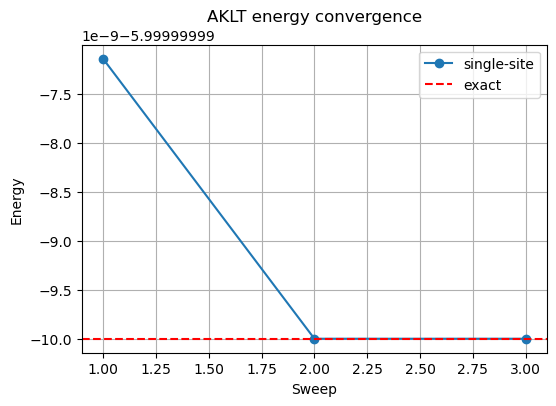

saved: figureAKLT\aklt_energy_convergence.png


<Figure size 600x400 with 0 Axes>

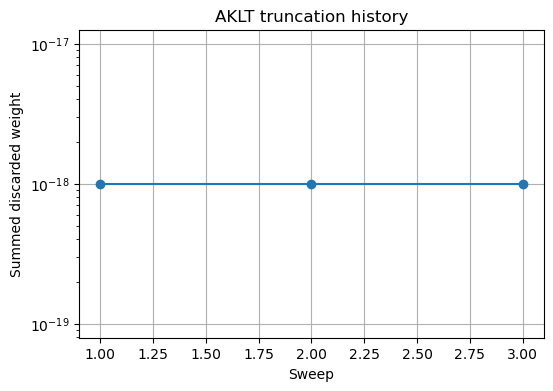

saved: figureAKLT\aklt_truncation_history.png


<Figure size 600x400 with 0 Axes>

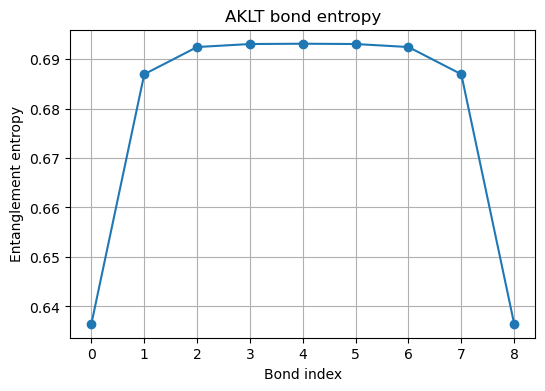

saved: figureAKLT\aklt_bond_entropy.png


<Figure size 600x400 with 0 Axes>

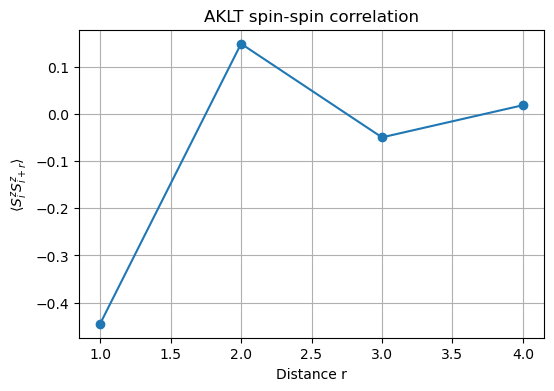

saved: figureAKLT\aklt_spinspin_corr.png


<Figure size 600x400 with 0 Axes>

In [30]:
L_aklt = 10
W_aklt, bL_aklt, bR_aklt = mpo_aklt(L_aklt)

mps_exact_aklt = normalize_mps(aklt_exact_mps(L_aklt))
E_exact_formula_aklt = -(L_aklt - 1) * (2/3)
E_exact_mps_aklt = mpo_expectation(mps_exact_aklt, W_aklt).real
print("AKLT exact MPS energy =", E_exact_mps_aklt)
print("AKLT exact formula    =", E_exact_formula_aklt)

mps0_aklt = normalize_mps(random_mps(L_aklt, d=3, Dmax=8, seed=7))
mps_aklt, Ehist_aklt, trunc_aklt, Sent_aklt = single_site_dmrg_fast_stop(
    W_aklt, mps0_aklt, bL_aklt, bR_aklt, Dmax=8,
    nsweeps=10, eig_tol=1e-10, svd_eps=1e-12,
    energy_tol=1e-10, min_sweeps=2, verbose=True
)
Efinal_aklt = mpo_expectation(mps_aklt, W_aklt).real
print("Single-site AKLT final energy =", Efinal_aklt)

mps0_aklt_2s = normalize_mps(random_mps(L_aklt, d=3, Dmax=8, seed=77))
mps_aklt_2s, Ehist_aklt_2s, trunc_aklt_2s = two_site_dmrg(
    W_aklt, mps0_aklt_2s, bL_aklt, bR_aklt, Dmax=8,
    nsweeps=4, eig_tol=1e-10, svd_eps=1e-12,
    energy_tol=1e-10, min_sweeps=2, verbose=True
)
Efinal_aklt_2s = mpo_expectation(mps_aklt_2s, W_aklt).real
print("Two-site AKLT final energy =", Efinal_aklt_2s)
print("Final AKLT bond dims =", [A.shape[2] for A in mps_aklt_2s[:-1]])

Sbond_aklt = exact_bond_entropies_from_state(mps_aklt)
ops1 = spin_one_ops()
Sz1 = ops1["Sz"]
i0_aklt = L_aklt // 2
dist_aklt = np.arange(1, min(8, L_aklt - i0_aklt))
corr_aklt = np.array([two_point_expectation(mps_aklt, Sz1, i0_aklt, Sz1, i0_aklt + r).real for r in dist_aklt])

plt.figure()
plt.plot(np.arange(1, len(Ehist_aklt)+1), Ehist_aklt, marker='o', label='single-site')
plt.axhline(E_exact_formula_aklt, color='r', ls='--', label='exact')
plt.xlabel("Sweep"); plt.ylabel("Energy"); plt.title("AKLT energy convergence")
plt.legend(); plt.show(); savefig("aklt_energy_convergence.png")

plt.figure()
plt.semilogy(np.arange(1, len(trunc_aklt)+1), np.maximum(trunc_aklt, 1e-18), marker='o')
plt.xlabel("Sweep"); plt.ylabel("Summed discarded weight"); plt.title("AKLT truncation history")
plt.show(); savefig("aklt_truncation_history.png")

plt.figure()
plt.plot(np.arange(len(Sbond_aklt)), Sbond_aklt, marker='o')
plt.xlabel("Bond index"); plt.ylabel("Entanglement entropy"); plt.title("AKLT bond entropy")
plt.show(); savefig("aklt_bond_entropy.png")

plt.figure()
plt.plot(dist_aklt, corr_aklt, marker='o')
plt.xlabel("Distance r"); plt.ylabel(r"$\langle S^z_i S^z_{i+r}\rangle$")
plt.title("AKLT spin-spin correlation")
plt.show(); savefig("aklt_spinspin_corr.png")

sweep  1: E = -4.258035207186, dE = nan, trunc_sum = 0.000e+00, Smax = 0.737869
sweep  2: E = -4.258035207209, dE = 2.358e-11, trunc_sum = 0.000e+00, Smax = 0.737869
Converged early: |dE| < 1e-10
Heisenberg L=10 final energy = -4.258035207209296
Reference = -4.258035207


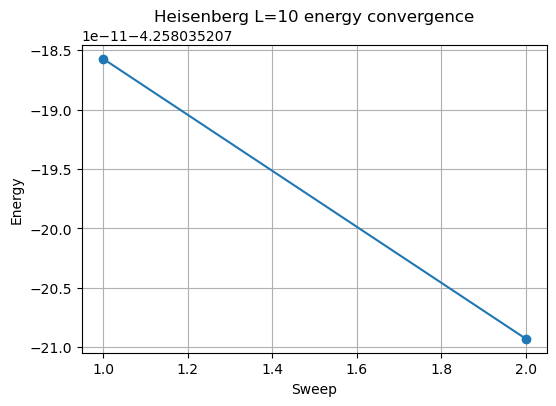

saved: figureAKLT\heisenberg_energy_convergence.png


<Figure size 600x400 with 0 Axes>

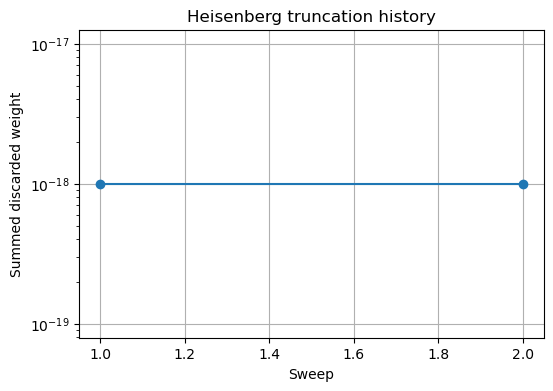

saved: figureAKLT\heisenberg_truncation_history.png


<Figure size 600x400 with 0 Axes>

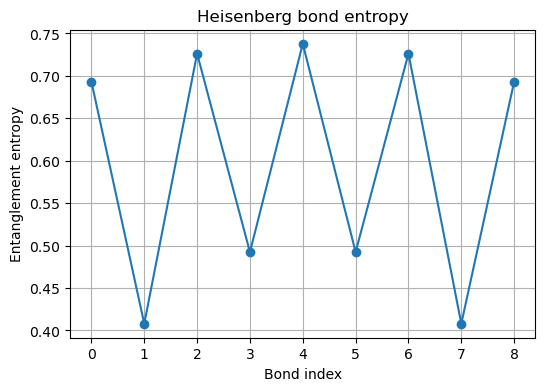

saved: figureAKLT\heisenberg_bond_entropy_exact_smallL.png


<Figure size 600x400 with 0 Axes>

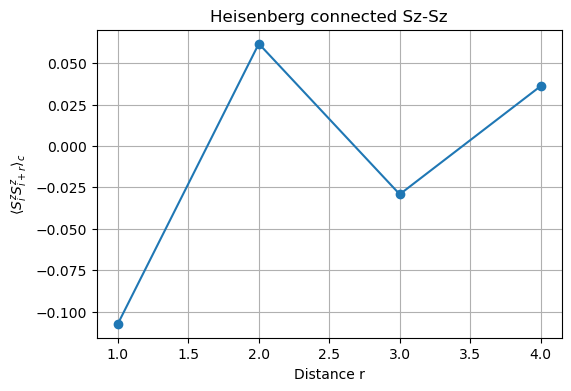

saved: figureAKLT\heisenberg_connected_corr_corrected.png


<Figure size 600x400 with 0 Axes>

In [31]:
L_heis = 10
W_heis, bL_heis, bR_heis = mpo_heisenberg(L_heis)

mps0_heis = normalize_mps(random_mps(L_heis, d=2, Dmax=24, seed=21))
mps_heis, Ehist_heis, trunc_heis, Sent_heis = single_site_dmrg_fast_stop(
    W_heis, mps0_heis, bL_heis, bR_heis, Dmax=24,
    nsweeps=10, eig_tol=1e-10, svd_eps=1e-12,
    energy_tol=1e-10, min_sweeps=2, verbose=True
)
Efinal_heis = mpo_expectation(mps_heis, W_heis).real
Eref_heis = -4.258035207
print("Heisenberg L=10 final energy =", Efinal_heis)
print("Reference =", Eref_heis)

Sbond_heis = exact_bond_entropies_from_state(mps_heis)
ops12 = spin_half_ops()
Sz12 = ops12["Sz"]
i0_heis = L_heis // 2
dist_heis = np.arange(1, min(6, L_heis - i0_heis))
corr_heis = np.array([connected_two_point(mps_heis, Sz12, i0_heis, i0_heis + r).real for r in dist_heis])

plt.figure()
plt.plot(np.arange(1, len(Ehist_heis)+1), Ehist_heis, marker='o')
plt.xlabel("Sweep"); plt.ylabel("Energy"); plt.title("Heisenberg L=10 energy convergence")
plt.show(); savefig("heisenberg_energy_convergence.png")

plt.figure()
plt.semilogy(np.arange(1, len(trunc_heis)+1), np.maximum(trunc_heis, 1e-18), marker='o')
plt.xlabel("Sweep"); plt.ylabel("Summed discarded weight"); plt.title("Heisenberg truncation history")
plt.show(); savefig("heisenberg_truncation_history.png")

plt.figure()
plt.plot(np.arange(len(Sbond_heis)), Sbond_heis, marker='o')
plt.xlabel("Bond index"); plt.ylabel("Entanglement entropy"); plt.title("Heisenberg bond entropy")
plt.show(); savefig("heisenberg_bond_entropy_exact_smallL.png")

plt.figure()
plt.plot(dist_heis, corr_heis, marker='o')
plt.xlabel("Distance r"); plt.ylabel(r"$\langle S^z_i S^z_{i+r}\rangle_c$")
plt.title("Heisenberg connected Sz-Sz")
plt.show(); savefig("heisenberg_connected_corr_corrected.png")

sweep  1: E = -8.682473319644, dE = nan, trunc_sum = 4.468e-09, maxbond = 32
sweep  2: E = -8.682473319650, dE = 6.146e-12, trunc_sum = 6.728e-09, maxbond = 32
Converged early: |dE| < 1e-09
Two-site Heisenberg L=20 energy = -8.682473319650136
Two-site runtime (min) = 1.7096835772196453
sweep  1: E = -8.682473319689, dE = nan, trunc_sum = 0.000e+00, Smax = 0.792414
sweep  2: E = -8.682473319690, dE = 8.455e-13, trunc_sum = 0.000e+00, Smax = 0.792414
Converged early: |dE| < 1e-10
Refined Heisenberg L=20 energy = -8.682473319690148
Refinement runtime (min) = 1.615543250242869


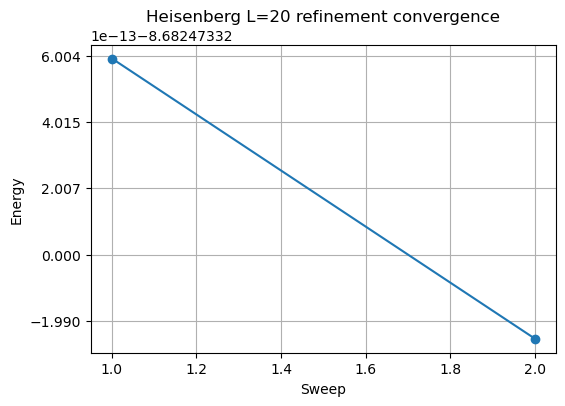

saved: figureAKLT\heisenberg_L20_refinement_convergence.png


<Figure size 600x400 with 0 Axes>

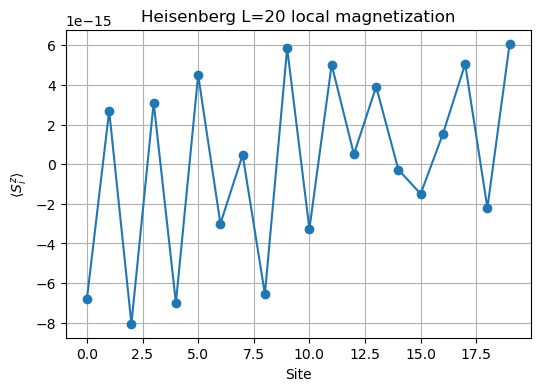

saved: figureAKLT\heisenberg_L20_local_magnetization.png


<Figure size 600x400 with 0 Axes>

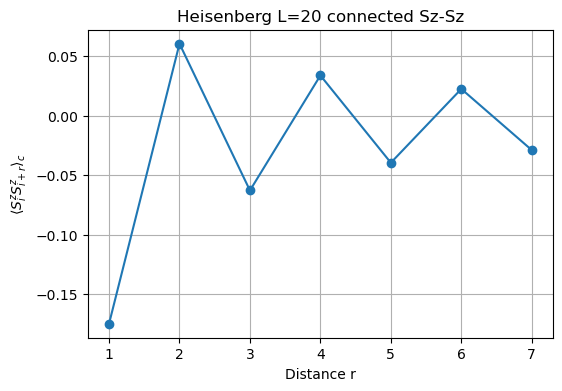

saved: figureAKLT\heisenberg_L20_connected_corr_final.png


<Figure size 600x400 with 0 Axes>

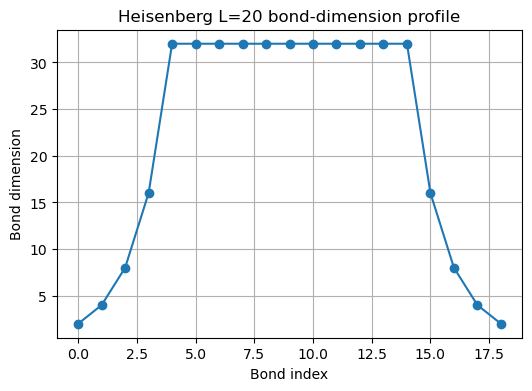

saved: figureAKLT\heisenberg_L20_bond_dimensions.png


<Figure size 600x400 with 0 Axes>

In [32]:
L_heis20 = 20
D_heis20 = 32
W_heis20, bL_heis20, bR_heis20 = mpo_heisenberg(L_heis20)

mps0_heis20 = normalize_mps(random_mps(L_heis20, d=2, Dmax=D_heis20, seed=2024))

t0 = time.time()
mps_heis20_2s, Ehist_heis20_2s, trunc_heis20_2s = two_site_dmrg(
    W_heis20, mps0_heis20, bL_heis20, bR_heis20, Dmax=D_heis20,
    nsweeps=4, eig_tol=1e-10, svd_eps=1e-12,
    energy_tol=1e-9, min_sweeps=2, verbose=True
)
t1 = time.time()
Efinal_heis20_2s = mpo_expectation(mps_heis20_2s, W_heis20).real
print("Two-site Heisenberg L=20 energy =", Efinal_heis20_2s)
print("Two-site runtime (min) =", (t1 - t0) / 60.0)

t2 = time.time()
mps_heis20, Ehist_heis20, trunc_heis20, Sent_heis20 = single_site_dmrg_fast_stop(
    W_heis20, mps_heis20_2s, bL_heis20, bR_heis20, Dmax=D_heis20,
    nsweeps=6, eig_tol=1e-10, svd_eps=1e-12,
    energy_tol=1e-10, min_sweeps=1, verbose=True
)
t3 = time.time()
Efinal_heis20 = mpo_expectation(mps_heis20, W_heis20).real
print("Refined Heisenberg L=20 energy =", Efinal_heis20)
print("Refinement runtime (min) =", (t3 - t2) / 60.0)

mz_heis20 = np.array([one_site_expectation(mps_heis20, Sz12, i).real for i in range(L_heis20)])
i0 = L_heis20 // 2
dist = np.arange(1, min(8, L_heis20 - i0))
corr_heis20 = np.array([connected_two_point(mps_heis20, Sz12, i0, i0 + r).real for r in dist])
bond_dims_heis20 = [A.shape[2] for A in mps_heis20[:-1]]

plt.figure()
plt.plot(np.arange(1, len(Ehist_heis20)+1), Ehist_heis20, marker='o')
plt.xlabel("Sweep"); plt.ylabel("Energy"); plt.title("Heisenberg L=20 refinement convergence")
plt.show(); savefig("heisenberg_L20_refinement_convergence.png")

plt.figure()
plt.plot(np.arange(L_heis20), mz_heis20, marker='o')
plt.xlabel("Site"); plt.ylabel(r"$\langle S_i^z \rangle$")
plt.title("Heisenberg L=20 local magnetization")
plt.show(); savefig("heisenberg_L20_local_magnetization.png")

plt.figure()
plt.plot(dist, corr_heis20, marker='o')
plt.xlabel("Distance r"); plt.ylabel(r"$\langle S^z_i S^z_{i+r}\rangle_c$")
plt.title("Heisenberg L=20 connected Sz-Sz")
plt.show(); savefig("heisenberg_L20_connected_corr_final.png")

plt.figure()
plt.plot(np.arange(len(bond_dims_heis20)), bond_dims_heis20, marker='o')
plt.xlabel("Bond index"); plt.ylabel("Bond dimension")
plt.title("Heisenberg L=20 bond-dimension profile")
plt.show(); savefig("heisenberg_L20_bond_dimensions.png")

Heisenberg L=10 variance:
  <H> = -4.258035207209301
  <H^2> = 18.13086382623771
  var = 4.0375880416831933e-10
AKLT L=6 exact-MPS variance:
  <H> = -3.333333333333334
  <H^2> = 11.111111111111123
  var = 8.881784197001252e-15

AKLT string correlators:
(1, 2) -0.44449954921049806
(1, 3) -0.44449954921049695
(1, 4) -0.44449954921049567
(1, 5) -0.444499549210495
(1, 6) -0.4444995492104954
(1, 7) -0.44449954921049506
(1, 8) -0.4444995492104955


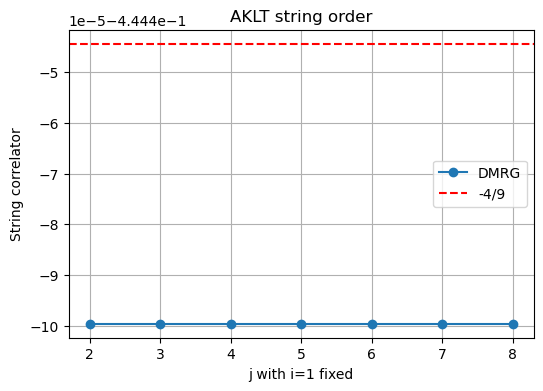

saved: figureAKLT\aklt_string_order.png


<Figure size 600x400 with 0 Axes>

In [33]:
# Variance
H_heis_10 = heisenberg_exact_hamiltonian(L_heis)
E_heis_var, H2_heis_var, var_heis = variance_from_statevector(mps_heis, H_heis_10)

L_aklt_var = 6
mps_aklt_var = normalize_mps(aklt_exact_mps(L_aklt_var))
H_aklt_6 = aklt_exact_hamiltonian(L_aklt_var)
E_aklt_var, H2_aklt_var, var_aklt = variance_from_statevector(mps_aklt_var, H_aklt_6)

print("Heisenberg L=10 variance:")
print("  <H> =", E_heis_var)
print("  <H^2> =", H2_heis_var)
print("  var =", var_heis)

print("AKLT L=6 exact-MPS variance:")
print("  <H> =", E_aklt_var)
print("  <H^2> =", H2_aklt_var)
print("  var =", var_aklt)

# AKLT string order
StringOp = np.diag(np.exp(1j * np.pi * np.diag(Sz1))).astype(np.complex128)
pairs, vals = [], []
for j in range(2, L_aklt - 1):
    v = string_correlator(mps_aklt, Sz1, StringOp, Sz1, 1, j).real
    pairs.append((1, j))
    vals.append(v)

print("\nAKLT string correlators:")
for p, v in zip(pairs, vals):
    print(p, v)

plt.figure()
plt.plot([j for (_, j) in pairs], vals, marker='o', label='DMRG')
plt.axhline(-4/9, color='r', ls='--', label='-4/9')
plt.xlabel("j with i=1 fixed")
plt.ylabel("String correlator")
plt.title("AKLT string order")
plt.legend()
plt.show(); savefig("aklt_string_order.png")

In [34]:
print("===== FINAL SUMMARY =====\n")

print("AKLT:")
print("  exact formula energy      =", E_exact_formula_aklt)
print("  exact MPS energy          =", E_exact_mps_aklt)
print("  single-site DMRG energy   =", Efinal_aklt)
print("  two-site DMRG energy      =", Efinal_aklt_2s)
print("  final two-site bond dims  =", [A.shape[2] for A in mps_aklt_2s[:-1]])
print()

print("Heisenberg L=10:")
print("  reference energy          =", Eref_heis)
print("  DMRG energy               =", Efinal_heis)
print("  variance                  =", var_heis)
print()

print("Heisenberg L=20:")
print("  two-site energy           =", Efinal_heis20_2s)
print("  refined energy            =", Efinal_heis20)
print("  final bond dims           =", [A.shape[2] for A in mps_heis20[:-1]])
print()

print("AKLT string order plateau ~")
for p, v in zip(pairs, vals):
    print(" ", p, "->", v)

print("\nSaved figures in", FIGDIR)
for f in sorted(os.listdir(FIGDIR)):
    print(" ", f)

===== FINAL SUMMARY =====

AKLT:
  exact formula energy      = -6.0
  exact MPS energy          = -6.000000000000001
  single-site DMRG energy   = -6.0000000000000036
  two-site DMRG energy      = -6.0000000000000036
  final two-site bond dims  = [2, 2, 2, 2, 2, 2, 2, 2, 2]

Heisenberg L=10:
  reference energy          = -4.258035207
  DMRG energy               = -4.258035207209296
  variance                  = 4.0375880416831933e-10

Heisenberg L=20:
  two-site energy           = -8.682473319650136
  refined energy            = -8.682473319690148
  final bond dims           = [2, 4, 8, 16, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 16, 8, 4, 2]

AKLT string order plateau ~
  (1, 2) -> -0.44449954921049806
  (1, 3) -> -0.44449954921049695
  (1, 4) -> -0.44449954921049567
  (1, 5) -> -0.444499549210495
  (1, 6) -> -0.4444995492104954
  (1, 7) -> -0.44449954921049506
  (1, 8) -> -0.4444995492104955

Saved figures in figureAKLT
  DMRG_convergence.png
  TwoSite_DMRG_convergence.png
  aklt